Titanic

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from config import config as cnf
import seaborn as sns

In [2]:
train_file = cnf.files.data + cnf.files.train
print(train_file)
df = pd.read_csv(train_file)

./data/train.csv


In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
useless_columns = ["Name", "Ticket"]

In [20]:
missing_data = pd.DataFrame({
'Missing Values': df.isnull().sum(),
'Percentage': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)
print(missing_data)

          Missing Values  Percentage
Cabin                687   77.104377
Age                  177   19.865320
Embarked               2    0.224467


Пропусков не слишком много в столбцах. К тому же Cabin не будет влиять на целевую переменную

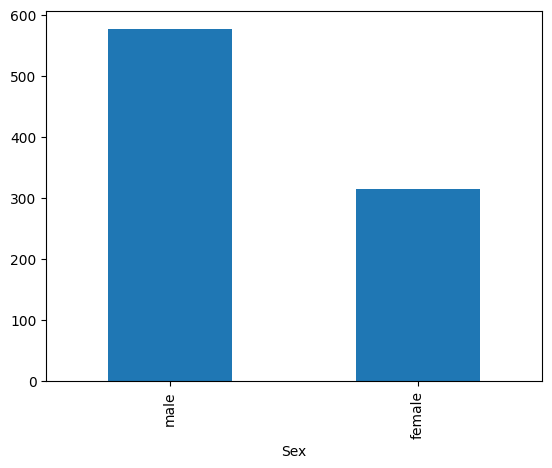

In [5]:
df["Sex"].value_counts().plot(x='Sex', kind='bar')
plt.show()

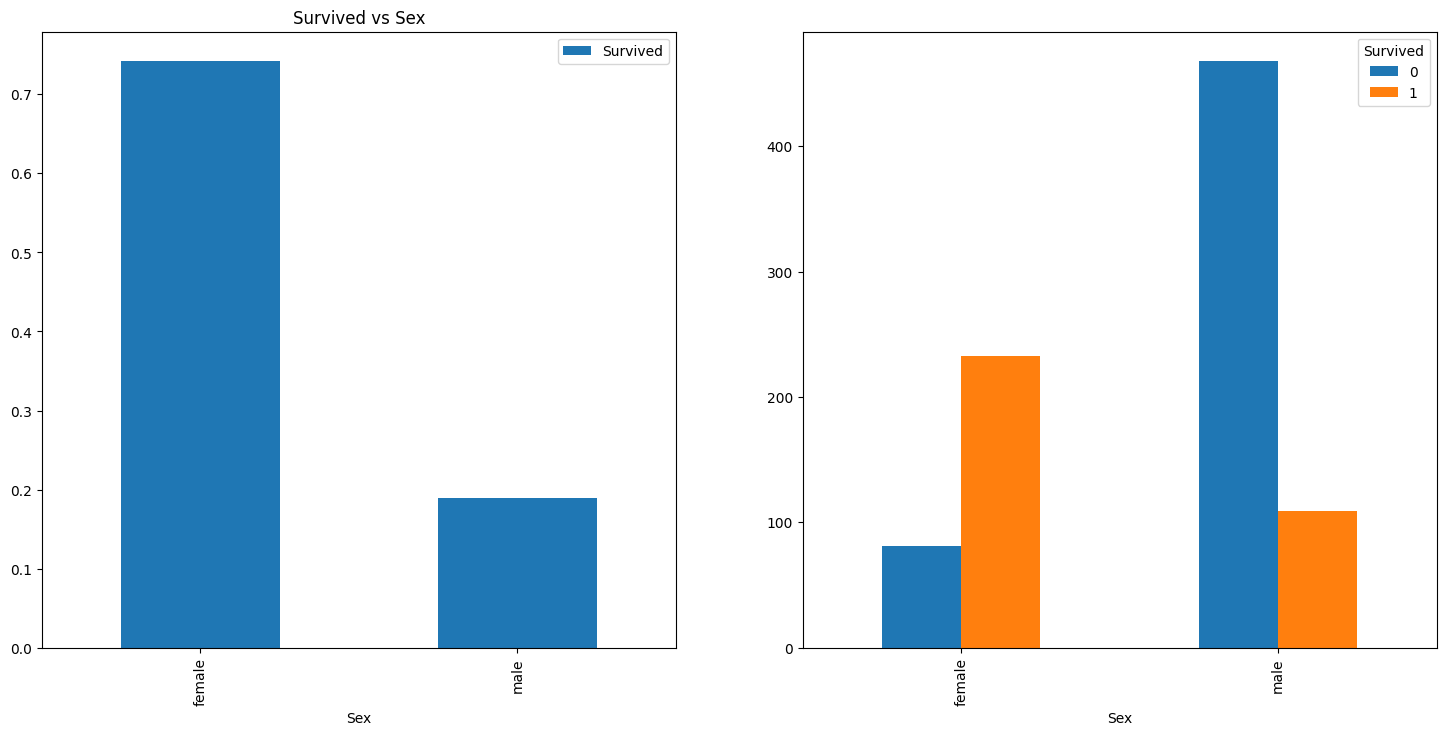

In [6]:
f,ax=plt.subplots(1,2,figsize=(18,8))
df[['Sex','Survived']].groupby(['Sex']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survived vs Sex')
pd.crosstab(df['Sex'], df['Survived']).plot.bar(ax=ax[1])
plt.show()

Из данного графика явно можем сделать вывод, что женщины в процентном соотношении выживали гораздо чаще мужчин. Даже в абсолютном значении чаще

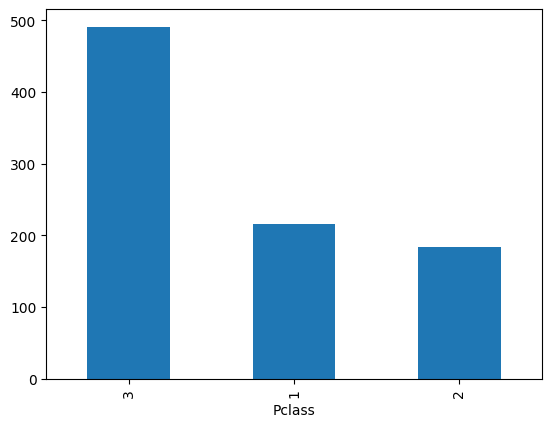

In [7]:
df["Pclass"].value_counts().plot(x='Class', kind='bar')
plt.show()

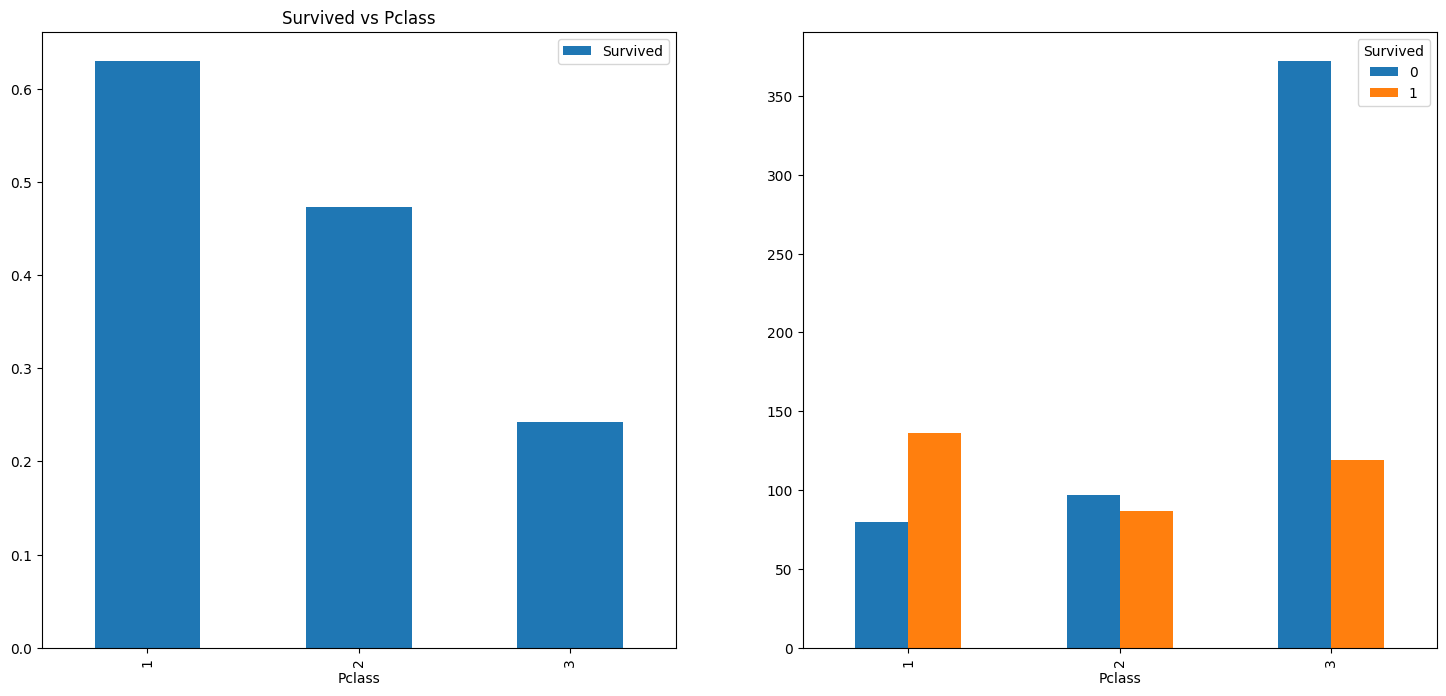

In [8]:
f,ax=plt.subplots(1,2,figsize=(18,8))
df[['Pclass','Survived']].groupby(['Pclass']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survived vs Pclass')
pd.crosstab(df['Pclass'], df['Survived']).plot.bar(ax=ax[1])
plt.show()

В процентном соотношении 1 класс выживает гораздо чаще. 3 класс выживает редко. 2 класс находится на довольно высоком уровне выживаемости

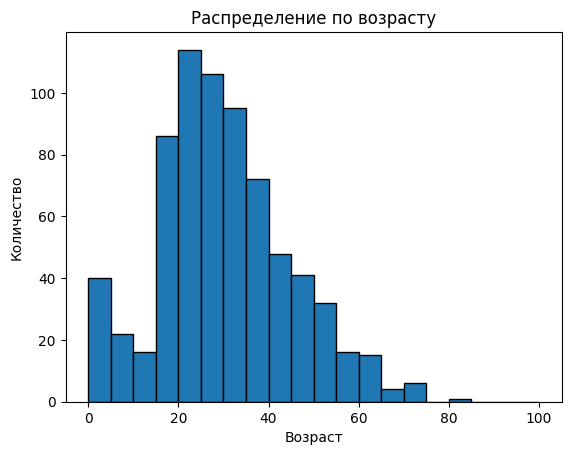

In [9]:

bins = range(0, 105, 5)

df['Age'].plot(kind='hist', bins=bins, edgecolor='black')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.title('Распределение по возрасту')
plt.show()

C:\Users\Faceless\AppData\Local\Temp\ipykernel_14208\3614041139.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['Age'], bins=bins, right=False))['Survived'].mean().plot.bar(


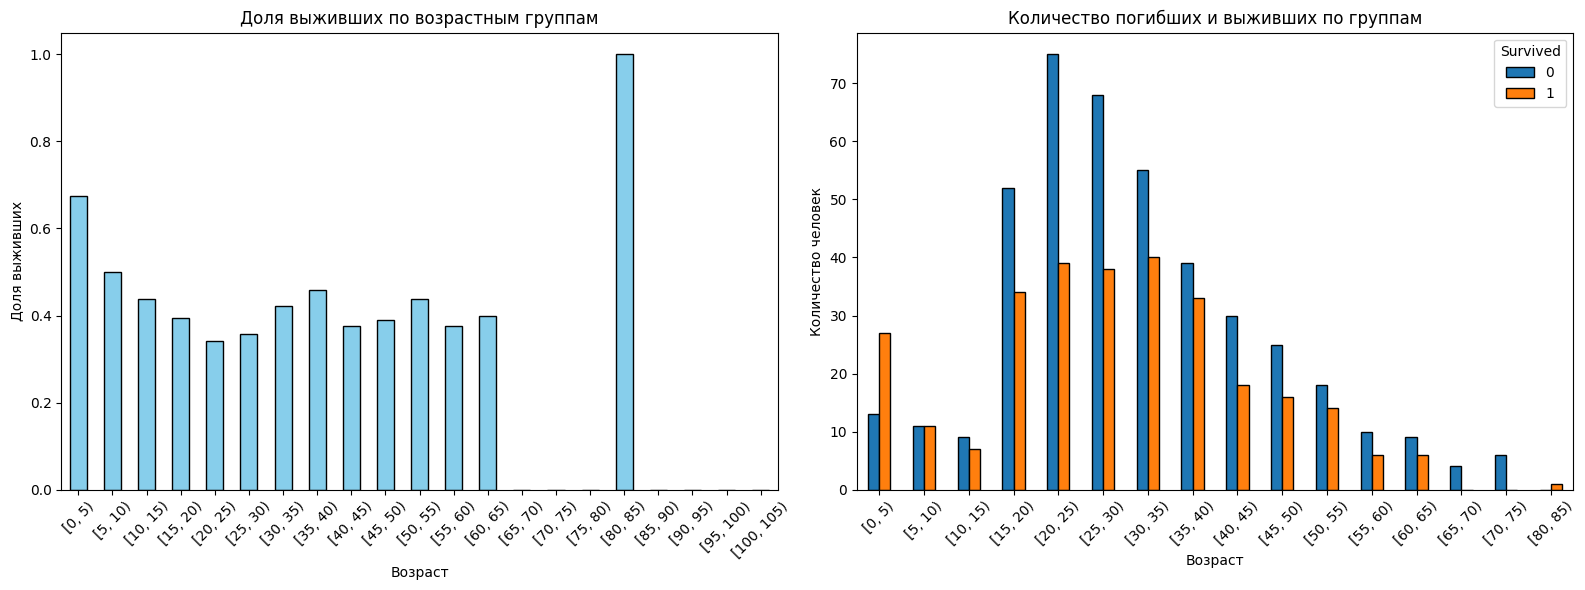

In [10]:
bins = range(0, 110, 5)

f, ax = plt.subplots(1, 2, figsize=(16, 6))

df.groupby(pd.cut(df['Age'], bins=bins, right=False))['Survived'].mean().plot.bar(
    ax=ax[0], color='skyblue', edgecolor='black'
)
ax[0].set_title('Доля выживших по возрастным группам')
ax[0].set_xlabel('Возраст')
ax[0].set_ylabel('Доля выживших')
ax[0].tick_params(axis='x', rotation=45)

pd.crosstab(
    pd.cut(df['Age'], bins=bins, right=False), df['Survived']
).plot.bar(ax=ax[1], edgecolor='black')
ax[1].set_title('Количество погибших и выживших по группам')
ax[1].set_xlabel('Возраст')
ax[1].set_ylabel('Количество человек')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Первый график не сильно информативен, единственное что могу заметить, что много выживших в первой половине графика ( среди более молодых)
Второй график представляет больший интерес. Распределение мне напоминает нормальное распределение так или иначе связанным с возрастом. Но при таком обьеме данных сложно будет подтвердить нормальность распределения

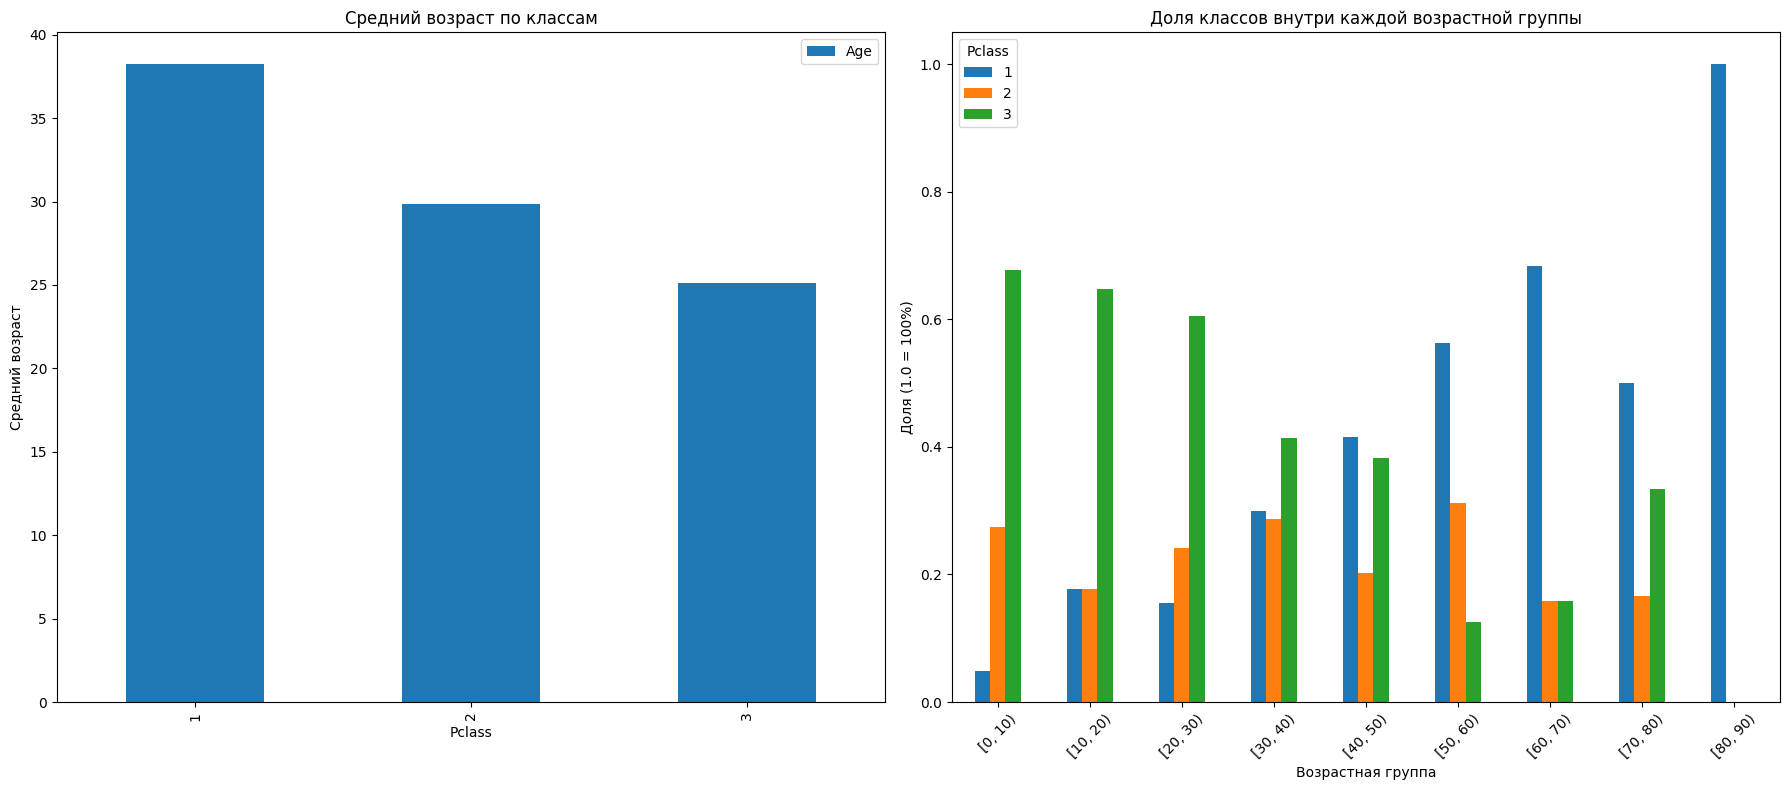

In [11]:

bins = range(0, 110, 10)

f, ax = plt.subplots(1, 2, figsize=(18, 8))

# Первый график
df[['Pclass', 'Age']].groupby(['Pclass']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Средний возраст по классам')
ax[0].set_ylabel('Средний возраст')


pd.crosstab(
    pd.cut(df['Age'], bins=bins, right=False), 
    df['Pclass'], 
    normalize='index'  
).plot.bar(ax=ax[1])

ax[1].set_title('Доля классов внутри каждой возрастной группы')
ax[1].set_xlabel('Возрастная группа')
ax[1].set_ylabel('Доля (1.0 = 100%)')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Интересный график номер 2. Тут мы явно видим что из 80 - 90 летних людей,  100% первый класс, и при уменьшении возраста все меньший процент людей первый класс и больший процент 3 класс. Но при этом 2 класс показывает относительную стабильность не зависимо от возраста

Но данная информация не позволяет сделать каких либо выводов

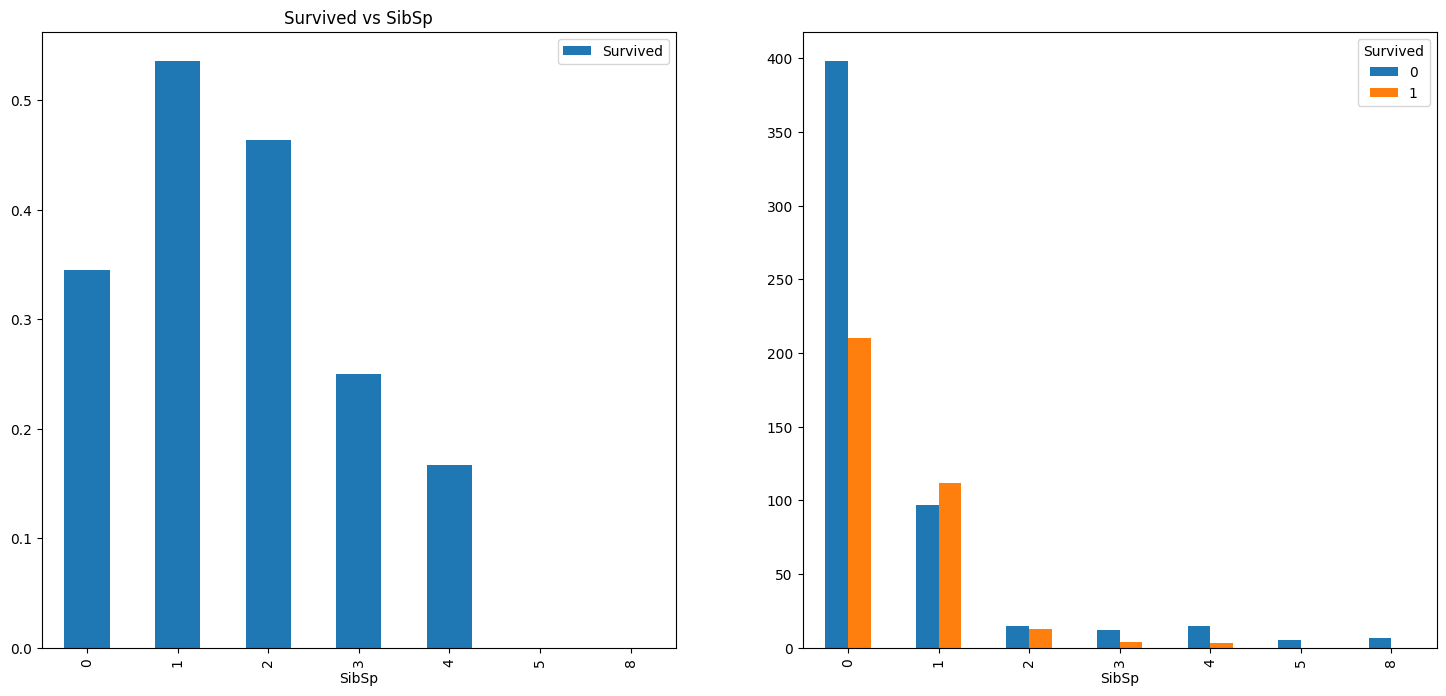

In [12]:
f,ax=plt.subplots(1,2,figsize=(18,8))
df[['SibSp','Survived']].groupby(['SibSp']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survived vs SibSp')
pd.crosstab(df['SibSp'], df['Survived']).plot.bar(ax=ax[1])
plt.show()

Видим интересную тенденцию, чем больше у человека родственников, тем меньше шанс выживания, видимо старались уступать друг другу места в спасательных шлюбках

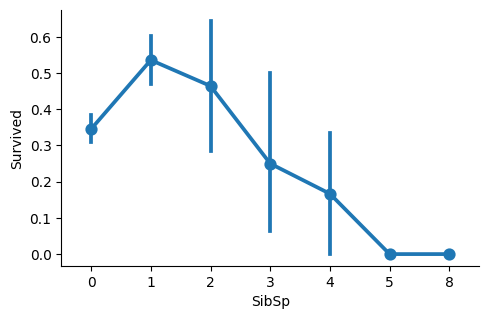

In [13]:
sns.catplot(x='SibSp', y='Survived',data=df, kind='point')
fig=plt.gcf()
fig.set_size_inches(5,3)
plt.show()

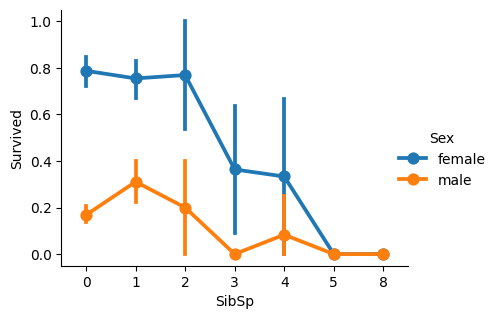

In [14]:
sns.catplot(x='SibSp', y='Survived' ,hue='Sex' ,data=df, kind='point')
fig=plt.gcf()
fig.set_size_inches(5,3)
plt.show()

Интересно, что независимо от количества родственников  шанс выживания у мужчин не переходил черту в 0.5. А у женщин ушло ниже 0.5 только при кол во родственников более 2

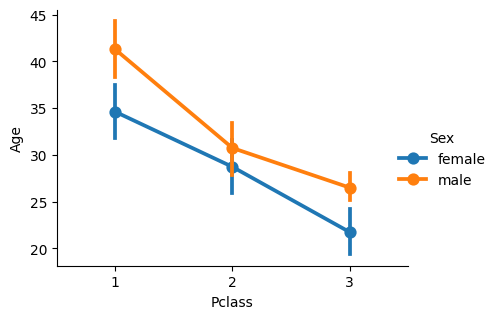

In [15]:
sns.catplot(x='Pclass', y='Age' ,hue='Sex' ,data=df, kind='point')
fig=plt.gcf()
fig.set_size_inches(5,3)
plt.show()

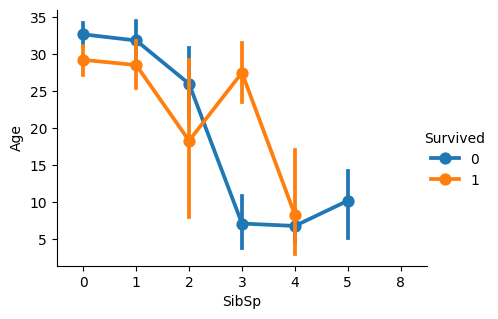

In [16]:
sns.catplot(x='SibSp', y='Age' ,hue='Survived' ,data=df, kind='point')
fig=plt.gcf()
fig.set_size_inches(5,3)
plt.show()

Как мы видим в целом большинство людей имело на корабле 2 родственников

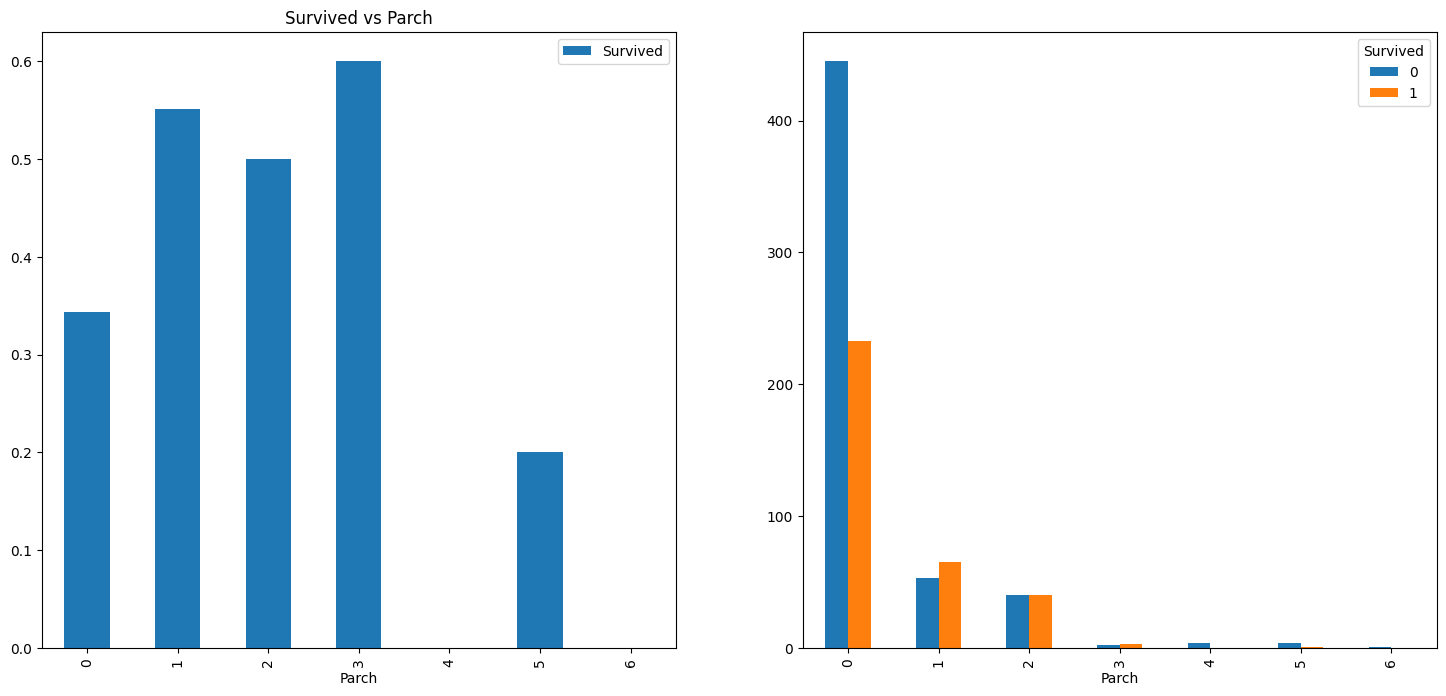

In [17]:
f,ax=plt.subplots(1,2,figsize=(18,8))
df[['Parch','Survived']].groupby(['Parch']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survived vs Parch')
pd.crosstab(df['Parch'], df['Survived']).plot.bar(ax=ax[1])
plt.show()

В целом видим аналогичную ситуацию с количеством своих родителей \ детей, люди уступают место своей семье места

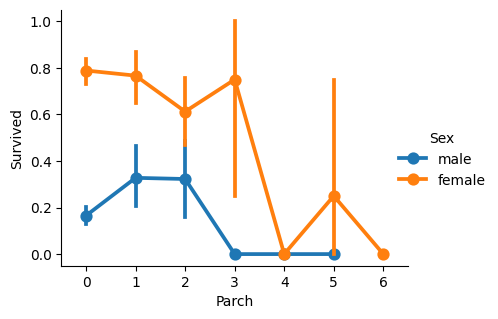

In [18]:
sns.catplot(x='Parch', y='Survived' ,hue='Sex' ,data=df, kind='point')
fig=plt.gcf()
fig.set_size_inches(5,3)
plt.show()

Но в данном случаи выживали гораздо более чаще, особенно в случае если они были частью семьи из 3 или 5 человек ( возможно были дочерьми или матерями )

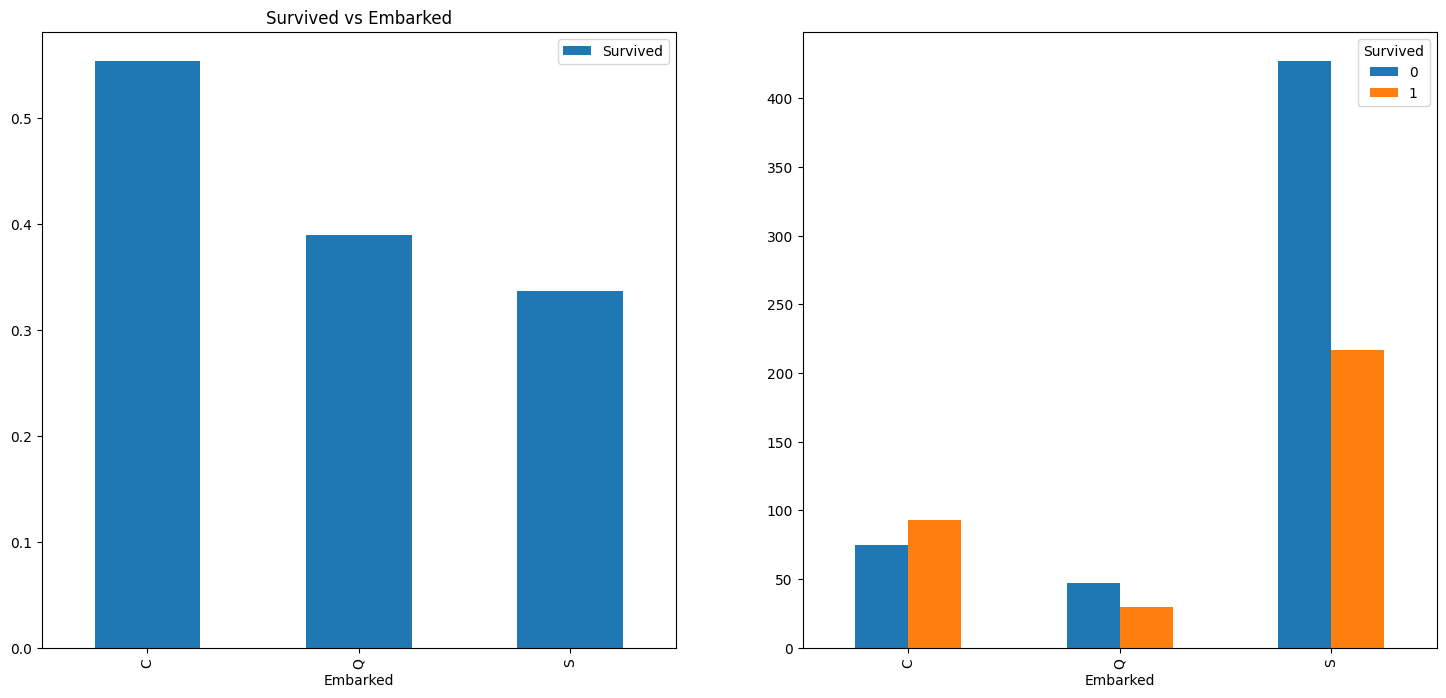

In [19]:
f,ax=plt.subplots(1,2,figsize=(18,8))
df[['Embarked','Survived']].groupby(['Embarked']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survived vs Embarked')
pd.crosstab(df['Embarked'], df['Survived']).plot.bar(ax=ax[1])
plt.show()

Минимальное кол во выживших людей в процентном соотношении, это порт S, но и в абсолютном значении все равно кол во погибших и выживших S. 

In [21]:

df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

df_numeric = df.drop(columns=['Name', 'Ticket', 'Embarked'], errors='ignore')
corr_matrix = df_numeric.corr(numeric_only=True)

print(corr_matrix['Survived'].sort_values(ascending=False))

Survived       1.000000
Sex            0.543351
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64


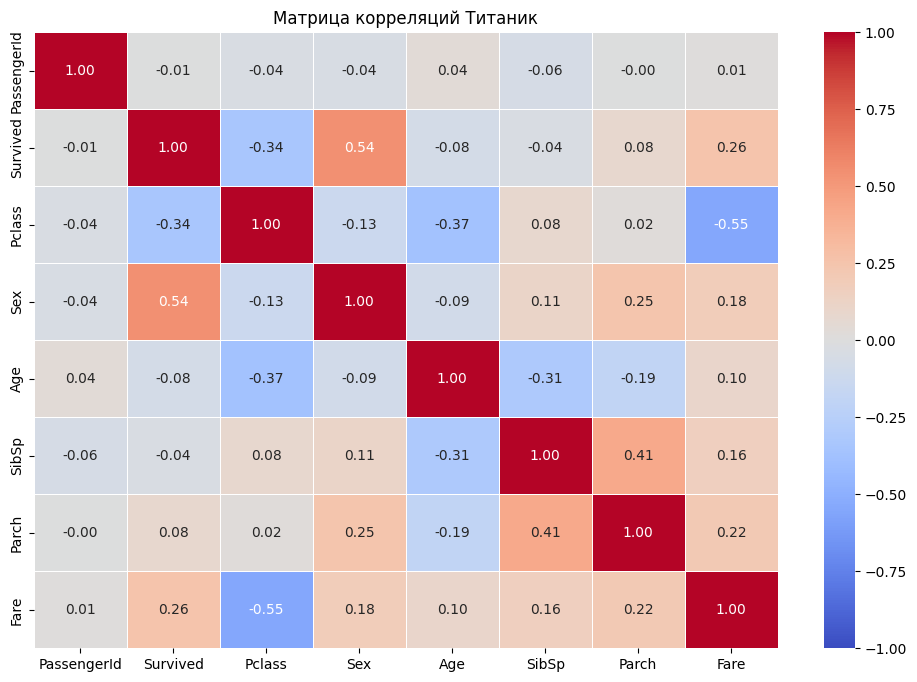

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8)) 

# Строим тепловую карту
sns.heatmap(
    corr_matrix, 
    annot=True,      
    fmt=".2f",       
    cmap='coolwarm', 
    linewidths=0.5, 
    vmin=-1, vmax=1  
)

plt.title('Матрица корреляций Титаник')
plt.show()